In [ ]:
#import Libraries
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.preprocessing import OneHotEncoder
import matplotlib.pyplot as plt
import seaborn as sns

In [ ]:
#load Dataset
df = pd.read_csv('/content/laptop_prices.csv')
print("Dataset reading complete")

Dataset reading complete


In [ ]:
df.shape

(1275, 23)

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1275 entries, 0 to 1274
Data columns (total 23 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   Company               1275 non-null   object 
 1   Product               1275 non-null   object 
 2   TypeName              1275 non-null   object 
 3   Inches                1275 non-null   float64
 4   Ram                   1275 non-null   int64  
 5   OS                    1275 non-null   object 
 6   Weight                1275 non-null   float64
 7   Price_euros           1275 non-null   float64
 8   Screen                1275 non-null   object 
 9   ScreenW               1275 non-null   int64  
 10  ScreenH               1275 non-null   int64  
 11  Touchscreen           1275 non-null   object 
 12  IPSpanel              1275 non-null   object 
 13  RetinaDisplay         1275 non-null   object 
 14  CPU_company           1275 non-null   object 
 15  CPU_freq             

In [ ]:
df.describe()

,Inches,Ram,Weight,Price_euros,ScreenW,ScreenH,CPU_freq,PrimaryStorage,SecondaryStorage
count,1275.000000,1275.000000,1275.000000,1275.000000,1275.000000,1275.000000,1275.000000,1275.000000,1275.000000
mean,15.022902,8.440784,2.040525,1134.969059,1900.043922,1073.904314,2.302980,444.517647,176.069020
std,1.429470,5.097809,0.669196,700.752504,493.346186,283.883940,0.503846,365.537726,415.960655
min,10.100000,2.000000,0.690000,174.000000,1366.000000,768.000000,0.900000,8.000000,0.000000
25%,14.000000,4.000000,1.500000,609.000000,1920.000000,1080.000000,2.000000,256.000000,0.000000
50%,15.600000,8.000000,2.040000,989.000000,1920.000000,1080.000000,2.500000,256.000000,0.000000
75%,15.600000,8.000000,2.310000,1496.500000,1920.000000,1080.000000,2.700000,512.000000,0.000000
max,18.400000,64.000000,4.700000,6099.000000,3840.000000,2160.000000,3.600000,2048.000000,2048.000000


In [ ]:
#Missing Values
df.isnull().sum()

,0
Company,0
Product,0
TypeName,0
Inches,0
Ram,0
OS,0
Weight,0
Price_euros,0
Screen,0
ScreenW,0


In [ ]:
# Count occurrences of each TypeName in the dataset
df['TypeName'].value_counts()

,count
TypeName,
Notebook,707
Gaming,205
Ultrabook,194
2 in 1 Convertible,117
Workstation,29
Netbook,23


In [ ]:
# Count occurrences of each Company in the dataset
df['Company'].value_counts()

,count
Company,
Dell,291
Lenovo,289
HP,268
Asus,152
Acer,101
MSI,54
Toshiba,48
Apple,21
Samsung,9


In [ ]:
# Count occurrences of each OS type in the dataset
df['OS'].value_counts()

,count
OS,
Windows 10,1048
No OS,66
Linux,58
Windows 7,45
Chrome OS,27
macOS,13
Mac OS X,8
Windows 10 S,8
Android,2


In [ ]:
# One-hot encoding
print("One-hot encoding for 'TypeName', 'Company' and 'OS' is already complete.")


One-hot encoding for 'TypeName', 'Company' and 'OS' is already complete.


In [ ]:
df.columns

Index(['Company', 'Product', 'TypeName', 'Inches', 'Ram', 'OS', 'Weight',
       'Price_euros', 'Screen', 'ScreenW', 'ScreenH', 'Touchscreen',
       'IPSpanel', 'RetinaDisplay', 'CPU_company', 'CPU_freq', 'CPU_model',
       'PrimaryStorage', 'SecondaryStorage', 'PrimaryStorageType',
       'SecondaryStorageType', 'GPU_company', 'GPU_model'],
      dtype='object')

In [ ]:
# Create feature matrix X by dropping 'Product', 'CPU_model', and 'Price_euros' columns
X = df.drop(['Product','CPU_model','Price_euros'], axis=1)
print("Feature matrix X created by dropping 'Product', 'CPU_model', and 'Price_euros' columns.")

Feature matrix X created by dropping 'Product', 'CPU_model', and 'Price_euros' columns.


In [ ]:
# Create target vector Y containing the 'Price_euros' column
Y = df['Price_euros']
print("Target vector Y created from 'Price_euros' column.")

Target vector Y created from 'Price_euros' column.


In [ ]:
X.head()

,Company,TypeName,Inches,Ram,OS,Weight,Screen,ScreenW,ScreenH,Touchscreen,IPSpanel,RetinaDisplay,CPU_company,CPU_freq,PrimaryStorage,SecondaryStorage,PrimaryStorageType,SecondaryStorageType,GPU_company,GPU_model
0,Apple,Ultrabook,13.3,8,macOS,1.37,Standard,2560,1600,No,Yes,Yes,Intel,2.3,128,0,SSD,No,Intel,Iris Plus Graphics 640
1,Apple,Ultrabook,13.3,8,macOS,1.34,Standard,1440,900,No,No,No,Intel,1.8,128,0,Flash Storage,No,Intel,HD Graphics 6000
2,HP,Notebook,15.6,8,No OS,1.86,Full HD,1920,1080,No,No,No,Intel,2.5,256,0,SSD,No,Intel,HD Graphics 620
3,Apple,Ultrabook,15.4,16,macOS,1.83,Standard,2880,1800,No,Yes,Yes,Intel,2.7,512,0,SSD,No,AMD,Radeon Pro 455
4,Apple,Ultrabook,13.3,8,macOS,1.37,Standard,2560,1600,No,Yes,Yes,Intel,3.1,256,0,SSD,No,Intel,Iris Plus Graphics 650


In [ ]:
Y.head()

,Price_euros
0,1339.69
1,898.94
2,575.00
3,2537.45
4,1803.60


In [ ]:
# Split the dataset into training and testing sets, then train a Linear Regression model
X_train, X_test, Y_train, Y_test = train_test_split(X, Y, test_size = 0.20, random_state = 42)
print("Model is tained and tested")

Model is tained and tested


In [ ]:
#Create the model
model = LinearRegression()

In [ ]:
#Train the Model
#model.fit(X_train, Y_train)
print("Model Trained on training data")

Model Trained on training data


In [ ]:
# Identify categorical columns for one-hot encoding
categorical_cols = X_train.select_dtypes(include='object').columns

ohe = OneHotEncoder(handle_unknown='ignore', sparse_output=False)

X_train_encoded = ohe.fit_transform(X_train[categorical_cols])
X_test_encoded = ohe.transform(X_test[categorical_cols])

X_train_encoded_df = pd.DataFrame(X_train_encoded, columns=ohe.get_feature_names_out(categorical_cols), index=X_train.index)
X_test_encoded_df = pd.DataFrame(X_test_encoded, columns=ohe.get_feature_names_out(categorical_cols), index=X_test.index)

X_train_numeric = X_train.drop(columns=categorical_cols)
X_test_numeric = X_test.drop(columns=categorical_cols)

X_train_processed = pd.concat([X_train_numeric, X_train_encoded_df], axis=1)
X_test_processed = pd.concat([X_test_numeric, X_test_encoded_df], axis=1)

print("Categorical features in X_train and X_test have been one-hot encoded.")

Categorical features in X_train and X_test have been one-hot encoded.


In [ ]:
# Train the Model with processed data
model.fit(X_train_processed, Y_train)
print("Model Trained on training data after one-hot encoding.")

Model Trained on training data after one-hot encoding.


In [ ]:
# Generate predictions for training and testing datasets using the trained model
Y_train_pred = model.predict(X_train_processed)
Y_test_pred = model.predict(X_test_processed)
print("Predictions generated for both Train and Test sets.")

Predictions generated for both Train and Test sets.


In [ ]:
# Evaluate model performance on training data using MAE, MSE, RMSE, and R2 score
mae = mean_absolute_error(Y_train, Y_train_pred)
mse = mean_squared_error(Y_train, Y_train_pred)
rmse = np.sqrt(mse)
r2 = r2_score(Y_train, Y_train_pred)
print("\nAfter model Training:")
print("Mean Absolute Error (MAE):", mae)
print("Mean Squared Error (MSE):", mse)
print("Root MSE (RMSE):", rmse)
print("R2 Score:", r2)

# Evaluate model performance on testing data using MAE, MSE, RMSE, and R2 score
mae = mean_absolute_error(Y_test, Y_test_pred)
mse = mean_squared_error(Y_test, Y_test_pred)
rmse = np.sqrt(mse)
r2 = r2_score(Y_test, Y_test_pred)
print("\nAfter model Testing:")
print("Mean Absolute Error (MAE):", mae)
print("Mean Squared Error (MSE):", mse)
print("Root MSE (RMSE):", rmse)
print("R2 Score:", r2)


After model Training:
Mean Absolute Error (MAE): 181.75680389856046
Mean Squared Error (MSE): 63063.37048319689
Root MSE (RMSE): 251.12421325550608
R2 Score: 0.8709629517883446

After model Testing:
Mean Absolute Error (MAE): 229.00835758814208
Mean Squared Error (MSE): 94345.22343633352
Root MSE (RMSE): 307.15667571507134
R2 Score: 0.8099178762753699


In [ ]:
# Retrieve the learned coefficients and intercept of the linear regression model
print("Coefficients:", model.coef_)
print("Intercept:", model.intercept_)

Coefficients: [ 4.43763648e+00  4.52476740e+01 -8.70218186e+01  2.29549182e+00
 -3.12102924e+00  1.97284669e+02  7.96344054e-02 -1.20698994e-01
 -2.27999564e+02 -3.75270556e+02 -2.20329235e+02 -3.59796762e+02
 -9.72173073e+01 -2.07108551e+02  5.32430753e+02 -5.72447672e+01
  4.41448065e+02  5.84797215e+02 -1.00994263e+02 -8.30678126e+01
 -3.26881985e+02  4.64665168e+02  6.80567172e+02 -7.59885239e+01
 -1.03377474e+01 -4.23517861e+02 -1.38153435e+02  5.96157262e+01
 -4.45768315e+02 -9.81300610e+01 -2.56551333e+02  9.20417626e+01
  6.48792220e+02 -1.24792954e+01 -4.24353797e+01  4.19933843e+01
 -1.92313612e+02 -1.07172028e+02  1.18089614e+02 -4.95046551e+00
  3.82224727e+02 -1.82956944e+02 -4.23556644e+02  2.46151462e+02
 -2.76754810e+02  4.54159992e+02  3.65166146e+01 -3.65166146e+01
 -1.10652645e+00  1.10652646e+00 -1.92520752e+02  1.92520752e+02
 -1.81006110e+02  1.48985420e+02  3.20206905e+01  3.01144896e+01
 -3.51295691e+01 -1.21494644e+02  1.26509724e+02  2.29466030e+01
  6.1760383

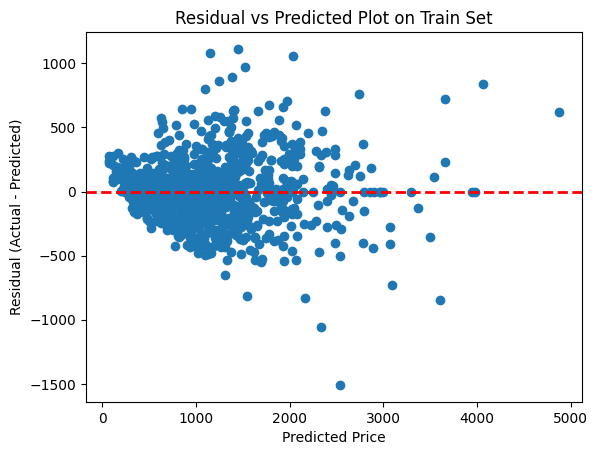

In [ ]:
# Plot residuals against predicted values on training data to analyze error patterns
residuals = Y_train - Y_train_pred
plt.scatter(Y_train_pred, residuals)
plt.axhline(0, color='red', linestyle='--', linewidth=2)
plt.xlabel("Predicted Price")
plt.ylabel("Residual (Actual - Predicted)")
plt.title("Residual vs Predicted Plot on Train Set")
plt.show()



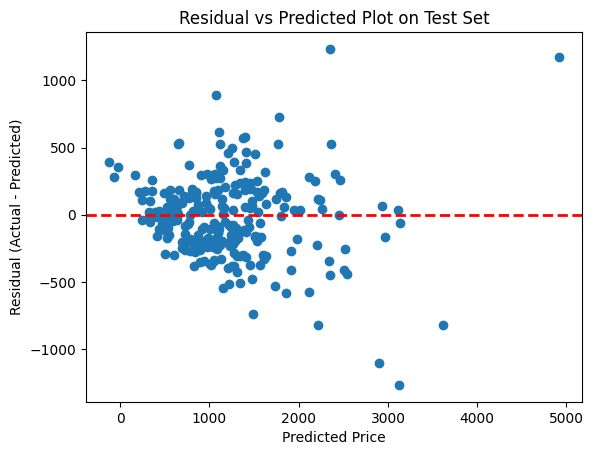

In [ ]:
# Plot residuals against predicted values on testing data to assess model generalization
residuals = Y_test - Y_test_pred
plt.scatter(Y_test_pred, residuals)
plt.axhline(0, color='red', linestyle='--', linewidth=2)
plt.xlabel("Predicted Price")
plt.ylabel("Residual (Actual - Predicted)")
plt.title("Residual vs Predicted Plot on Test Set")
plt.show()